In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV, LassoCV


In [4]:
df = pd.read_csv('insurance.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
# Estadísticas descriptivas de variables numéricas
desc_num = df.describe()
desc_num


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


: 

In [5]:
# Frecuencia de variables categóricas
desc_cat = df[['sex', 'smoker', 'region']].value_counts().reset_index(name='count')
desc_cat

,sex,smoker,region,count
0,female,no,southwest,141
1,female,no,southeast,139
2,female,no,northwest,135
3,male,no,southeast,134
4,male,no,northwest,132
5,female,no,northeast,132
6,male,no,southwest,126
7,male,no,northeast,125
8,male,yes,southeast,55
9,male,yes,northeast,38


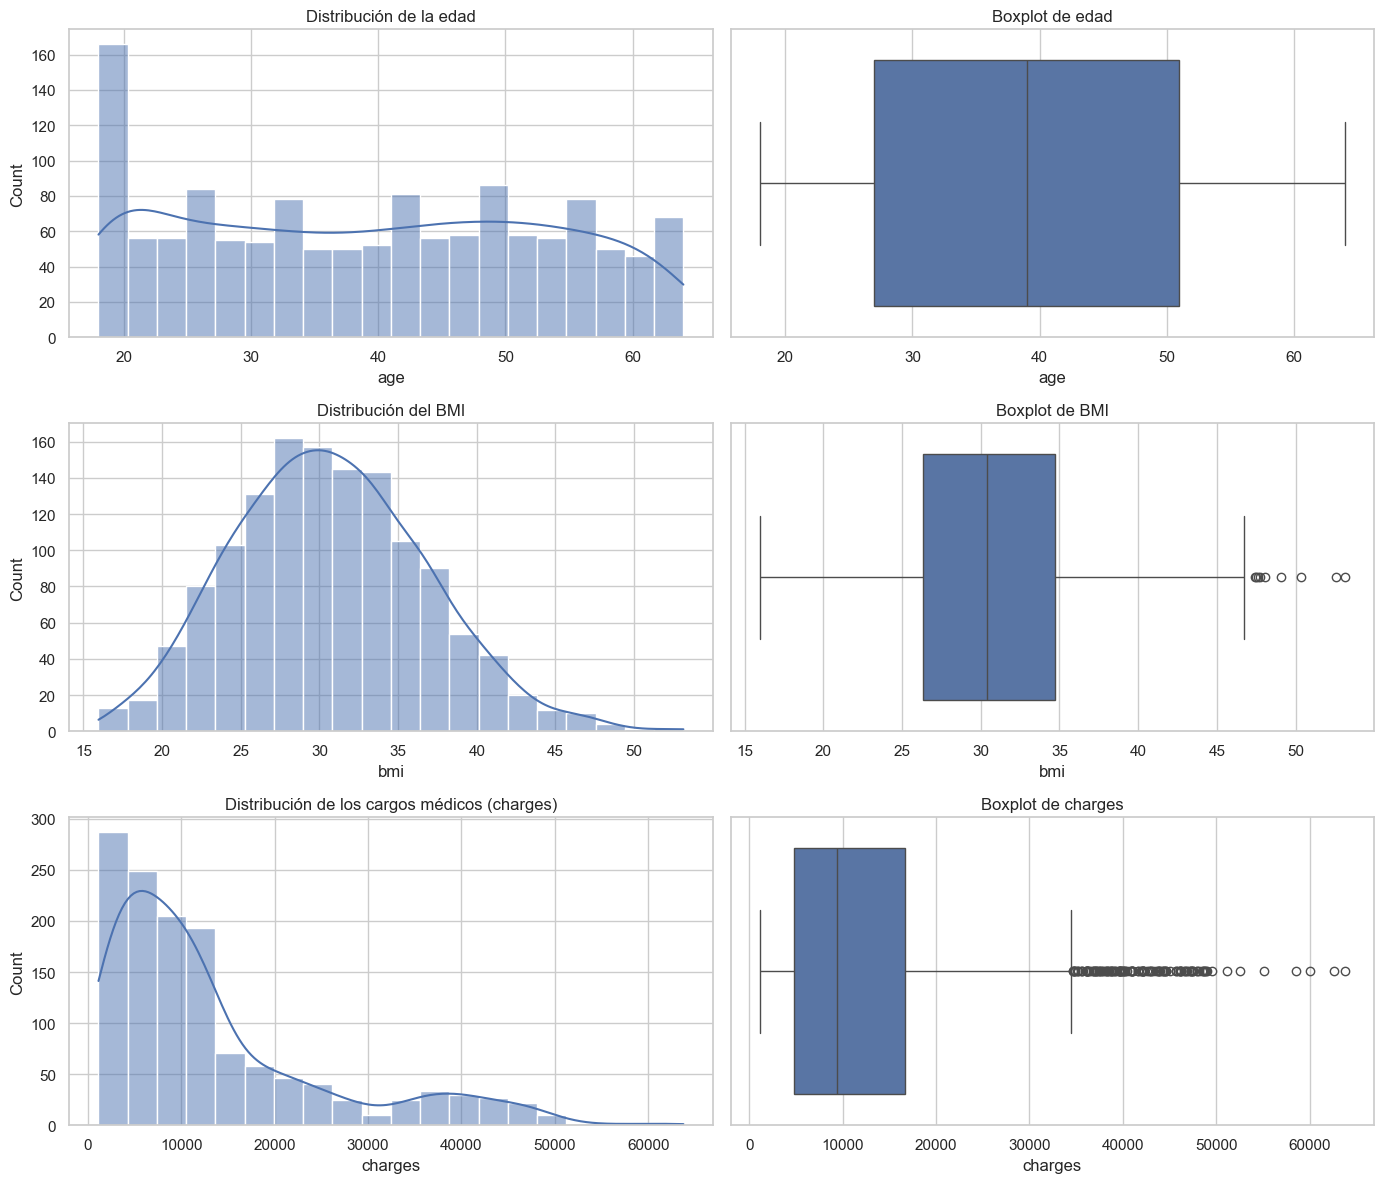

: 

In [ ]:
# Estilo general
sns.set(style="whitegrid")

# Crear figura con subplots para variables numéricas
fig, axs = plt.subplots(3, 2, figsize=(14, 12))

# Variable: age
sns.histplot(df['age'], kde=True, bins=20, ax=axs[0, 0])
axs[0, 0].set_title("Distribución de la edad")
sns.boxplot(x=df['age'], ax=axs[0, 1])
axs[0, 1].set_title("Boxplot de edad")

# Variable: bmi
sns.histplot(df['bmi'], kde=True, bins=20, ax=axs[1, 0])
axs[1, 0].set_title("Distribución del BMI")
sns.boxplot(x=df['bmi'], ax=axs[1, 1])
axs[1, 1].set_title("Boxplot de BMI")

# Variable: charges
sns.histplot(df['charges'], kde=True, bins=20, ax=axs[2, 0])
axs[2, 0].set_title("Distribución de los cargos médicos (charges)")
sns.boxplot(x=df['charges'], ax=axs[2, 1])
axs[2, 1].set_title("Boxplot de charges")

plt.tight_layout()
plt.show()


- Edad :La variable age no presenta sesgo evidente y puede ser usada directamente en el modelo. Su dispersión es moderada.
- Índice de Masa Corporal (bmi):Aunque la distribución es razonablemente simétrica, los valores extremos deben analizarse. Podrían tener impacto en el modelo si no se transforman o winsorizan.
- Debido al fuerte sesgo y presencia de outliers, se recomienda transformar esta variable (por ejemplo, log(charges)) para mejorar el ajuste del modelo y cumplir con los supuestos de regresión lineal.

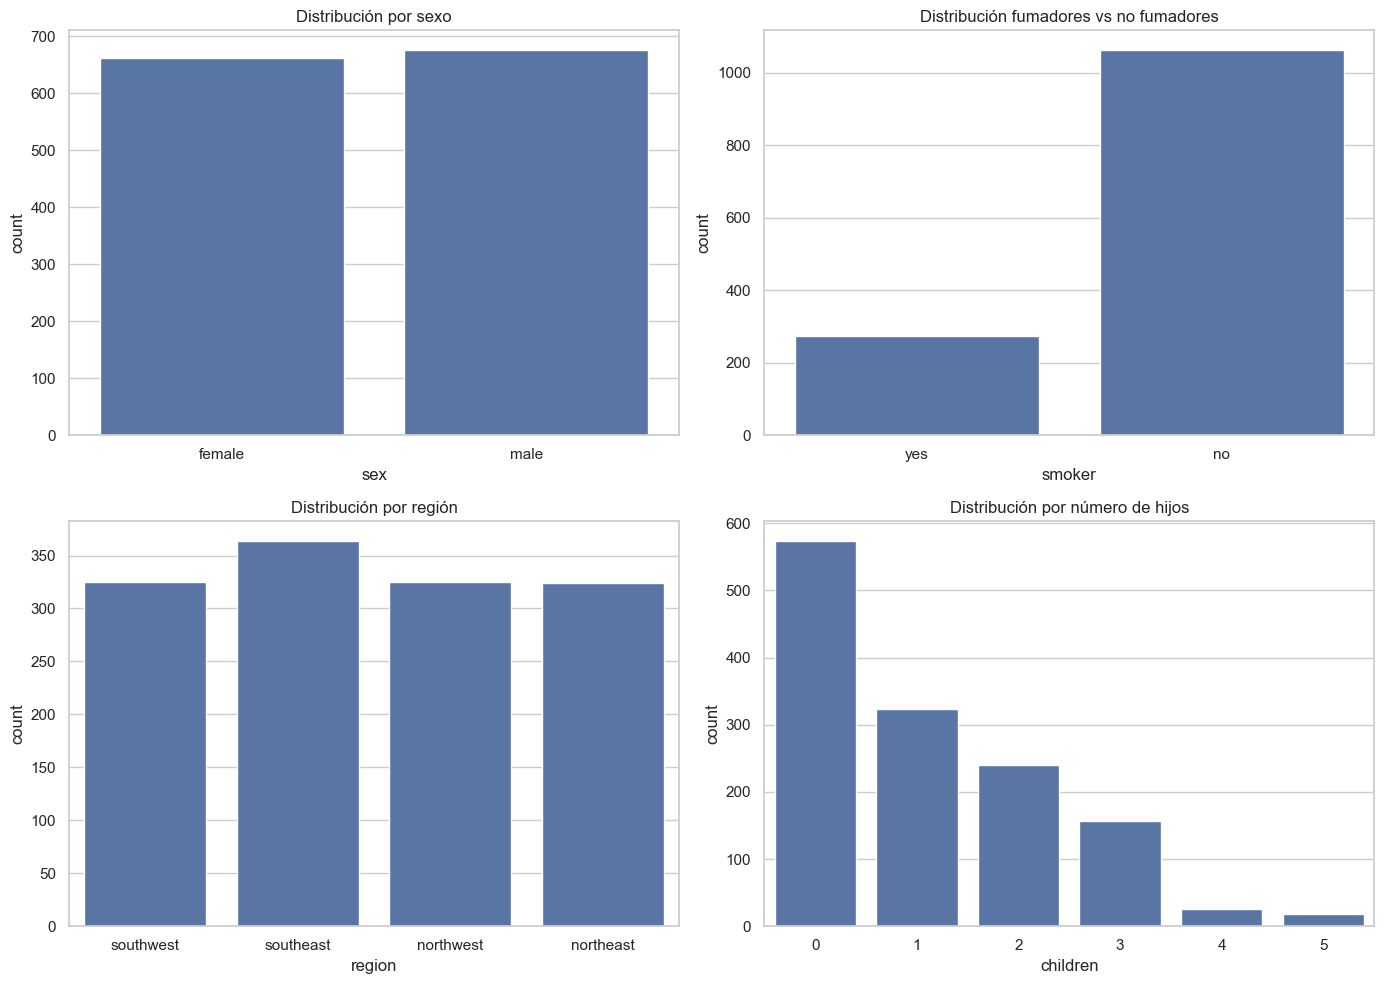

: 

In [ ]:
# Crear figura para variables categóricas
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# sex
sns.countplot(data=df, x='sex', ax=axs[0, 0])
axs[0, 0].set_title("Distribución por sexo")

# smoker
sns.countplot(data=df, x='smoker', ax=axs[0, 1])
axs[0, 1].set_title("Distribución fumadores vs no fumadores")

# region
sns.countplot(data=df, x='region', ax=axs[1, 0])
axs[1, 0].set_title("Distribución por región")

# children
sns.countplot(data=df, x='children', ax=axs[1, 1])
axs[1, 1].set_title("Distribución por número de hijos")

plt.tight_layout()
plt.show()


-  Sexo (sex): Esta variable está equilibrada y puede ser usada sin recodificación adicional para modelos que soporten variables categóricas. En modelos numéricos, se puede codificar con 0 = female y 1 = male.

- Hábito de fumar (smoker): Esta variable tiene una relación potencialmente fuerte con los cargos médicos (charges), ya que el tabaquismo suele asociarse a mayores riesgos de salud. Se recomienda codificación binaria 1 = smoker, 0 = non-smoker.

- Región (region): Al estar bien distribuida, esta variable puede ser útil para capturar variaciones geográficas en los costos médicos. Debe codificarse con dummies (one-hot encoding) si se utiliza en modelos lineales.
- Número d:e hijos (children): Aunque la variable es discreta, puede ser tratada como numérica ordinal en modelos lineales. Puede tener efecto en los cargos médicos, especialmente por la cobertura de seguros familiares.


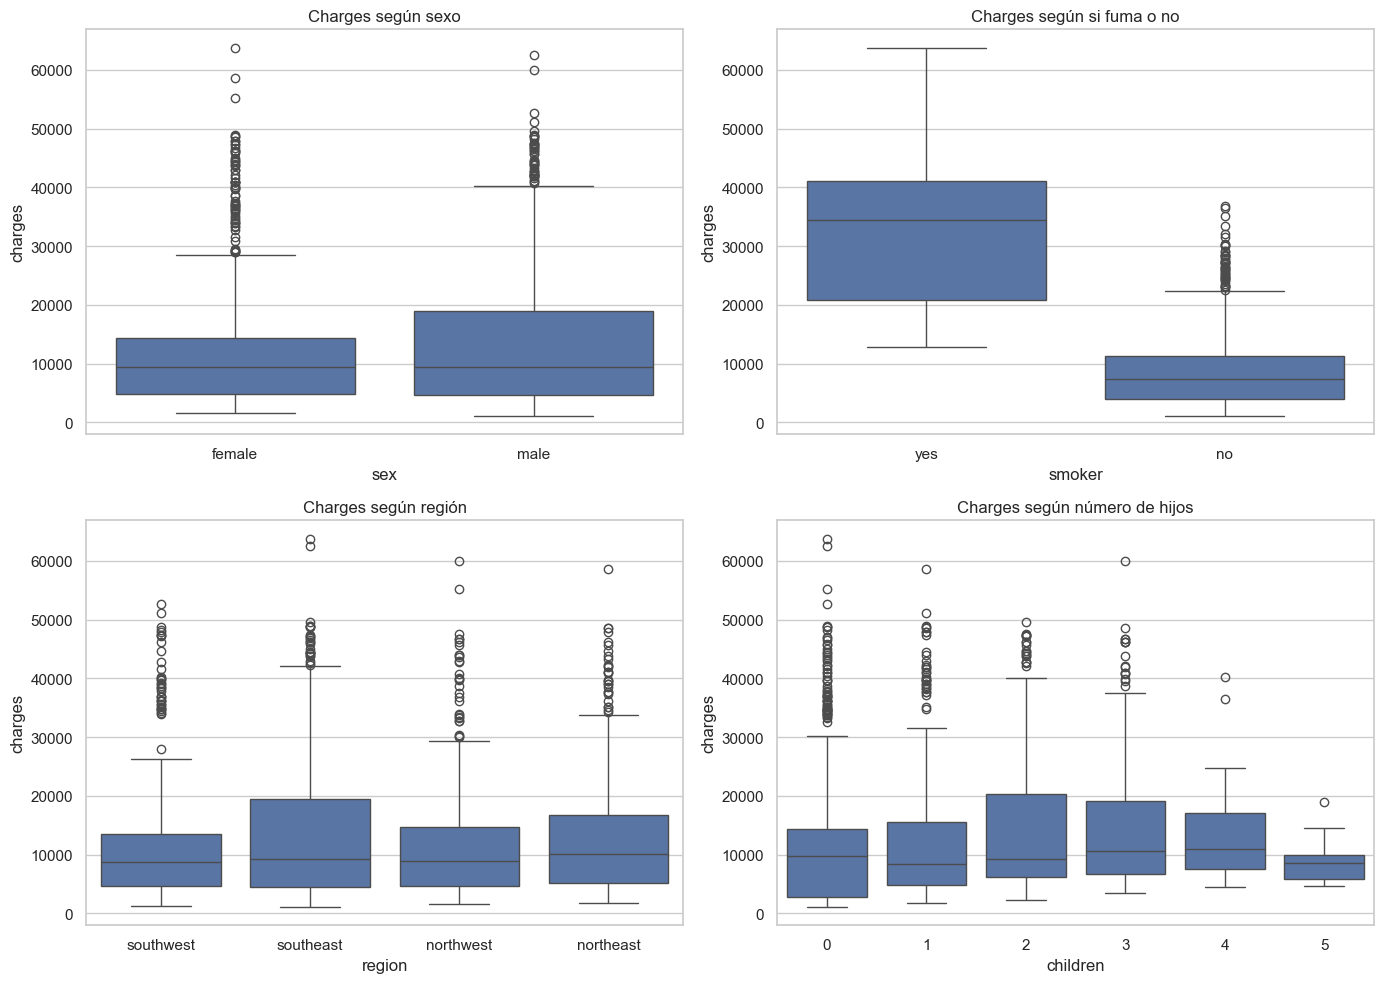

: 

In [ ]:
# Crear figura para boxplots de charges vs categóricas
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# sex vs charges
sns.boxplot(data=df, x='sex', y='charges', ax=axs[0, 0])
axs[0, 0].set_title("Charges según sexo")

# smoker vs charges
sns.boxplot(data=df, x='smoker', y='charges', ax=axs[0, 1])
axs[0, 1].set_title("Charges según si fuma o no")

# region vs charges
sns.boxplot(data=df, x='region', y='charges', ax=axs[1, 0])
axs[1, 0].set_title("Charges según región")

# children vs charges
sns.boxplot(data=df, x='children', y='charges', ax=axs[1, 1])
axs[1, 1].set_title("Charges según número de hijos")

plt.tight_layout()
plt.show()


- No se evidencian diferencias sustanciales entre hombres y mujeres en los cargos médicos. La mediana es muy similar para ambos grupos.
-  Los fumadores tienen cargos médicos significativamente más altos. La mediana y el rango intercuartílico están muy por encima del grupo de no fumadores.
- Las diferencias entre regiones son mínimas. El grupo southeast muestra una mediana ligeramente superior, pero no parece ser una diferencia sustancial
- La mediana de los cargos no varía sustancialmente con el número de hijos, y hay gran dispersión en todos los grupos.


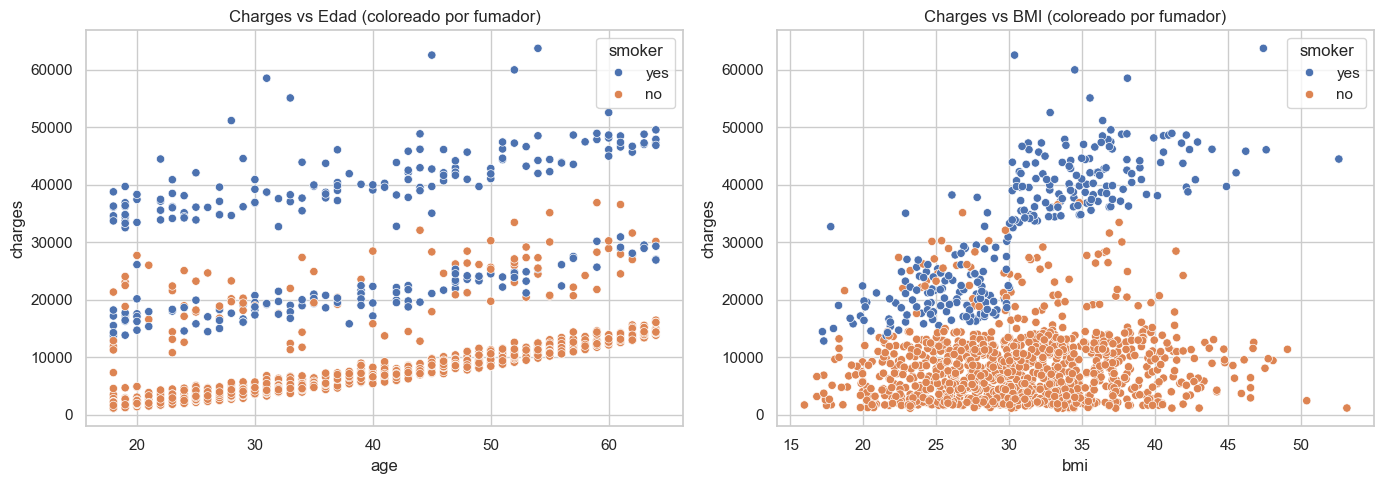

: 

In [ ]:
# Crear figura para scatterplots
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# age vs charges
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', ax=axs[0])
axs[0].set_title("Charges vs Edad (coloreado por fumador)")

# bmi vs charges
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', ax=axs[1])
axs[1].set_title("Charges vs BMI (coloreado por fumador)")

plt.tight_layout()
plt.show()


- Existe una interacción evidente entre edad y tabaquismo. La edad incrementa el riesgo, pero ser fumador lo potencia.
- Existe una interacción evidente entre edad y tabaquismo. La edad incrementa el riesgo, pero ser fumador lo potencia.
- El índice de masa corporal por sí solo tiene una relación positiva con los cargos, pero se amplifica notablemente con el hábito de fumar.

## Manejo de valores atipicos

In [ ]:
# Definir umbrales para valores atípicos usando método IQR
q1 = df['charges'].quantile(0.25)
q3 = df['charges'].quantile(0.75)
iqr = q3 - q1
iqr

np.float64(11899.625365)

: 

In [ ]:
# Límites inferior y superior
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identificar cuántos valores están fuera de los límites
outliers = df[(df['charges'] < lower_bound) | (df['charges'] > upper_bound)]
n_outliers = outliers.shape[0]
porcentaje_outliers = (n_outliers / df.shape[0]) * 100

# Mostrar estadísticas clave
{
    "Límite inferior": lower_bound,
    "Límite superior": upper_bound,
    "N° de valores atípicos": n_outliers,
    "% del total": round(porcentaje_outliers, 2)
}


{'Límite inferior': np.float64(-13109.1508975),
 'Límite superior': np.float64(34489.350562499996),
 'N° de valores atípicos': 139,
 '% del total': 10.39}

: 

Posible rutas:
- transformación logaritmica
- winsorización
- segmentar modelos
- Mantener todos lo datos

Compararemos 3 modelos uno al mantener todos los valores, otro con la transformación logaritmica en la variable respuesta y segmentaremos modelos bajo la perspectiva de un modelo para fumadores y otro para no fumadores. Antes de aplicarlos vamos aplicar ingneria de variables basado en el análisis exploratorio.

## Ingeneria de variables


In [ ]:
# Agrupar en rangos: jóvenes, adultos, mayores
df['age_group'] = pd.cut(df['age'], bins=[17, 30, 50, 65], labels=['young', 'adult', 'senior'])

: 

In [ ]:
# Clasificación del IMC
df['bmi_group'] = pd.cut(df['bmi'], bins=[0, 18.5, 24.9, 29.9, 40, 60],
                         labels=['underweight', 'normal', 'overweight', 'obese', 'extreme_obese'])

: 

In [ ]:
df['children_group'] = pd.cut(df['children'], bins=[-1, 0, 2, df['children'].max()],
                              labels=['no_children', 'few_children', 'many_children'])

: 

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'age_group', 'bmi_group', 'children_group'],
      dtype='object')

: 

Aparte de la discretización contruiremos.
- age_smoker = age * smoker_bin : es igual a la edad solo si la persona es fumadora, si no fuma, el valor es cero. esto permite capturar el impacto especifico de la edad en personas fumadoras.

- bmi_smoker = bmi * smoker_bin: Es igual al BMI solo si es fumador, 0 en caso contrario. Permite medir si el riesgo por obesidad afecta mas a quienes fuman.

- age_bmi = age * bmi: Es la interacción directa entre edad y BMI para todos. Esta interacción permite modelar si una persona mayor con sobrepeso tiene un riesgo más alto que lo que edad y BMI individualmente indicarían.

In [ ]:
# Copia del DataFrame para transformación
df_model = df.copy()

: 

In [ ]:
# Codificar 'smoker' como variable binaria (sí = 1, no = 0)
df_model['smoker_bin'] = df_model['smoker'].map({'yes': 1, 'no': 0})


: 

In [ ]:
# Crear variables de interacción
df_model['age_smoker'] = df_model['age'] * df_model['smoker_bin']
df_model['bmi_smoker'] = df_model['bmi'] * df_model['smoker_bin']
df_model['age_bmi'] = df_model['age'] * df_model['bmi']



: 

In [ ]:
# Mostrar primeras filas para inspección
df_model[['age', 'smoker', 'smoker_bin', 'age_smoker', 'bmi', 'bmi_smoker', 'age_bmi']].head()

,age,smoker,smoker_bin,age_smoker,bmi,bmi_smoker,age_bmi
0,19,yes,1,19,27.900,27.9,530.100
1,18,no,0,0,33.770,0.0,607.860
2,28,no,0,0,33.000,0.0,924.000
3,33,no,0,0,22.705,0.0,749.265
4,32,no,0,0,28.880,0.0,924.160


: 

In [ ]:
df_model

,age,sex,bmi,children,smoker,region,charges,age_group,bmi_group,children_group,smoker_bin,age_smoker,bmi_smoker,age_bmi
0,19,female,27.900,0,yes,southwest,16884.92400,young,overweight,no_children,1,19,27.90,530.100
1,18,male,33.770,1,no,southeast,1725.55230,young,obese,few_children,0,0,0.00,607.860
2,28,male,33.000,3,no,southeast,4449.46200,young,obese,many_children,0,0,0.00,924.000
3,33,male,22.705,0,no,northwest,21984.47061,adult,normal,no_children,0,0,0.00,749.265
4,32,male,28.880,0,no,northwest,3866.85520,adult,overweight,no_children,0,0,0.00,924.160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,adult,obese,many_children,0,0,0.00,1548.500
1334,18,female,31.920,0,no,northeast,2205.98080,young,obese,no_children,0,0,0.00,574.560
1335,18,female,36.850,0,no,southeast,1629.83350,young,obese,no_children,0,0,0.00,663.300
1336,21,female,25.800,0,no,southwest,2007.94500,young,overweight,no_children,0,0,0.00,541.800


: 

In [ ]:
# Mostrar primeras filas de las nuevas variables
df_model[['age', 'age_group', 'bmi', 'bmi_group', 'children', 'children_group']].head(10)


,age,age_group,bmi,bmi_group,children,children_group
0,19,young,27.900,overweight,0,no_children
1,18,young,33.770,obese,1,few_children
2,28,young,33.000,obese,3,many_children
3,33,adult,22.705,normal,0,no_children
4,32,adult,28.880,overweight,0,no_children
5,31,adult,25.740,overweight,0,no_children
6,46,adult,33.440,obese,1,few_children
7,37,adult,27.740,overweight,3,many_children
8,37,adult,29.830,overweight,2,few_children
9,60,senior,25.840,overweight,0,no_children


: 

In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             1338 non-null   int64   
 1   sex             1338 non-null   object  
 2   bmi             1338 non-null   float64 
 3   children        1338 non-null   int64   
 4   smoker          1338 non-null   object  
 5   region          1338 non-null   object  
 6   charges         1338 non-null   float64 
 7   age_group       1338 non-null   category
 8   bmi_group       1338 non-null   category
 9   children_group  1338 non-null   category
 10  smoker_bin      1338 non-null   int64   
 11  age_smoker      1338 non-null   int64   
 12  bmi_smoker      1338 non-null   float64 
 13  age_bmi         1338 non-null   float64 
dtypes: category(3), float64(4), int64(4), object(3)
memory usage: 119.5+ KB


: 

In [ ]:
df_model.drop(columns=['smoker', 'bmi', 'children', 'age'], inplace=True)

: 

In [ ]:
# Variable objetivo
y = df_model['charges']

# Variables predictoras
X = df_model.drop(columns=['charges'])


: 

In [ ]:
X

,sex,region,age_group,bmi_group,children_group,smoker_bin,age_smoker,bmi_smoker,age_bmi
0,female,southwest,young,overweight,no_children,1,19,27.90,530.100
1,male,southeast,young,obese,few_children,0,0,0.00,607.860
2,male,southeast,young,obese,many_children,0,0,0.00,924.000
3,male,northwest,adult,normal,no_children,0,0,0.00,749.265
4,male,northwest,adult,overweight,no_children,0,0,0.00,924.160
...,...,...,...,...,...,...,...,...,...
1333,male,northwest,adult,obese,many_children,0,0,0.00,1548.500
1334,female,northeast,young,obese,no_children,0,0,0.00,574.560
1335,female,southeast,young,obese,no_children,0,0,0.00,663.300
1336,female,southwest,young,overweight,no_children,0,0,0.00,541.800


: 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


: 

In [ ]:
# Variables categóricas a codificar (OneHot)
categorical_features = ['sex', 'region', 'age_group', 'bmi_group', 'children_group']

# Variables numéricas a escalar
numeric_features = ['age_smoker', 'bmi_smoker', 'age_bmi', 'smoker_bin']

: 

In [ ]:
# Preprocesadores


categorical_transformer = OneHotEncoder(drop='first')
numeric_transformer = StandardScaler()

# Pipeline de preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numeric_transformer, numeric_features)
    ]
)




: 

In [ ]:
# Modelo de regresión lineal
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regression', LinearRegression())
])

: 

In [ ]:
model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

: 

In [ ]:
# Predicciones
y_pred = model.predict(X_test)

: 

In [ ]:
# Métricas de evaluación
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
r2_adj = 1 - (1 - r2) * ((len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1))

# Resultados
{
    "R2": round(r2, 4),
    "R2 ajustado": round(r2_adj, 4),
    "MSE": round(mse, 2),
    "RMSE": round(rmse, 2)
}

{'R2': 0.864, 'R2 ajustado': 0.8593, 'MSE': 21112569.59, 'RMSE': 4594.84}

: 

In [ ]:
# Extraer coeficientes del modelo junto con los nombres de las variables
# Obtener nombres de variables transformadas
feature_names = model.named_steps['preprocessing'].get_feature_names_out()

# Extraer coeficientes del modelo
coefs = model.named_steps['regression'].coef_

# Crear DataFrame ordenado
coef_df = pd.DataFrame({
    'Variable': feature_names,
    'Coeficiente': coefs
}).sort_values(by='Coeficiente', key=abs, ascending=False)

coef_df


,Variable,Coeficiente
13,num__bmi_smoker,18175.747007
15,num__smoker_bin,-8519.053885
9,cat__bmi_group_underweight,5927.680266
6,cat__bmi_group_normal,5579.100952
7,cat__bmi_group_obese,4567.068858
8,cat__bmi_group_overweight,3928.500563
14,num__age_bmi,2746.151500
4,cat__age_group_senior,2418.124269
3,cat__region_southwest,-1399.311138
2,cat__region_southeast,-1176.761239


: 

Interpretación de algunos coeficientes.
- num__bmi_smoker → +18,175.75
Cada unidad adicional en la interacción BMI * smoker_bin aumenta charges en 18 mil, lo que indica que el sobrepeso en fumadores dispara los costos.

- num__age_bmi → +2,746
A mayor edad y mayor BMI, más costos. El efecto conjunto aumenta significativamente.

- num__age_smoker → +408
El efecto combinado de ser fumador y envejecer también incrementa ligeramente los costos.

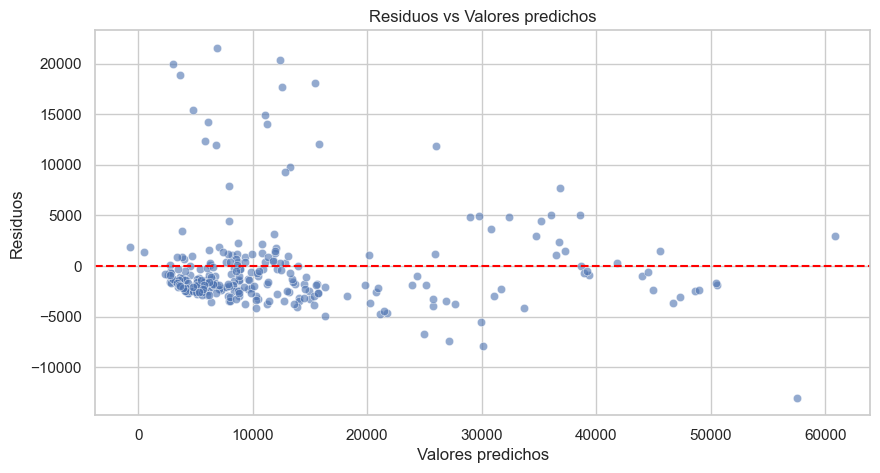

: 

In [ ]:
# Calcular residuos
residuos = y_test - y_pred

# Gráfico de residuos vs valores predichos
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred, y=residuos, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos vs Valores predichos")
plt.show()


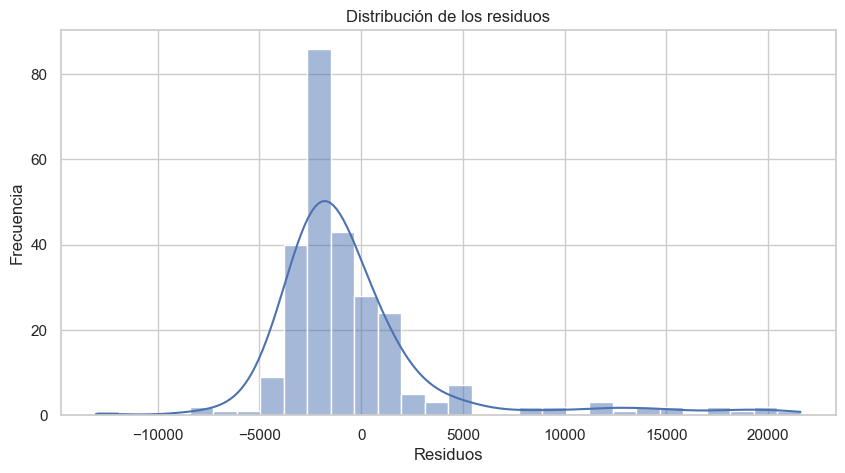

: 

In [ ]:
# Histograma de residuos
plt.figure(figsize=(10, 5))
sns.histplot(residuos, kde=True, bins=30)
plt.title("Distribución de los residuos")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.show()

## Prueba de Hipotesis y QQ-PLOT

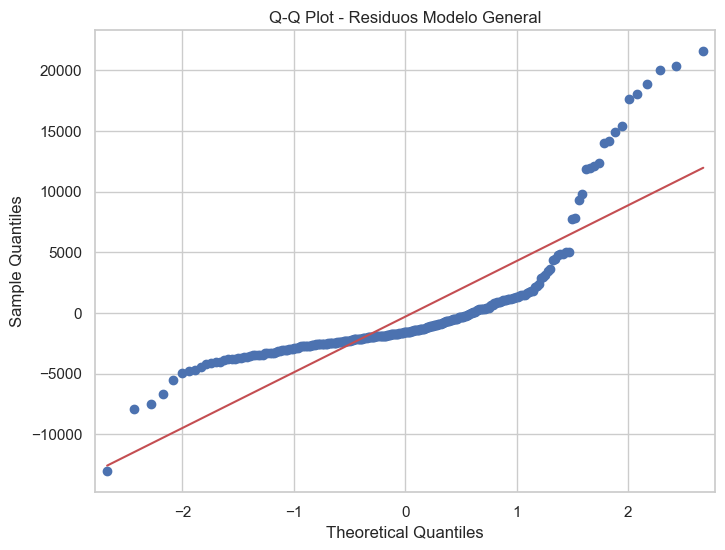

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     334.1
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:01:26   Log-Likelihood:                -10604.
No. Observations:                1070   AIC:                         2.124e+04
Df Residuals:                    1053   BIC:                         2.133e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.01e+04    842.460     11.992      0.000    8449.594    1.18e+04
x1          -574.9298    302.419     -1.901      0.058   -1168.343      18.483
x2          -663.1497    431.765     -1.536      0.125   -1510.367     184.067
x3         -1176.7612    430.312     -2.735      0.006   -2021.128    -332.395
x4         -1399.3111    430.480     -3.251      0.001   -2244.007    -554.615
x5          2418.1243    575.250      4.204      0.000    1289.358    3546.890
x6          -653.4422    565.993     -1.155      0.249   -1764.044     457.160
x7          5579.1010    976.114      5.716      0.000    3663.752    7494.450
x8          4567.0689    703.387      6.493      0.000    3186.868    5947.269
x9          3928.5006    840.546      4.674      0.000    2279.165    5577.836
x10         5927.6803   1672.464      3.544      0.000    2645.938    9209.423
x11          407.7658    449.933      0.906      0.365    -475.101    1290.632
x12        -1039.5820    343.027     -3.031      0.003   -1712.676    -366.488
x13          408.3487    440.290      0.927      0.354    -455.596    1272.294
x14         1.818e+04    762.074     23.850      0.000    1.67e+04    1.97e+04
x15         2746.1515    416.741      6.590      0.000    1928.414    3563.889
x16        -8519.0539    836.278    -10.187      0.000   -1.02e+04   -6878.094
==============================================================================
Omnibus:                      568.371   Durbin-Watson:                   2.060
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3334.308
Skew:                           2.480   Prob(JB):                         0.00
Kurtosis:                      10.085   Cond. No.                         23.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

: 

In [ ]:
shapiro_stat, shapiro_p = stats.shapiro(residuos)

fig, ax = plt.subplots(figsize=(8, 6))
sm.qqplot(residuos, line='s', ax=ax)
ax.set_title('Q-Q Plot - Residuos Modelo General')
plt.show()

X_train_transformed = model.named_steps['preprocessing'].transform(X_train)
X_train_sm = sm.add_constant(X_train_transformed)
model_sm = sm.OLS(y_train, X_train_sm).fit()
model_sm.summary()

In [ ]:
X_train_trans = model.named_steps['preprocessing'].transform(X_train)
X_test_trans = model.named_steps['preprocessing'].transform(X_test)
feature_names = model.named_steps['preprocessing'].get_feature_names_out()

coef_pvalues = pd.DataFrame({
    'feature': feature_names,
    'coef': model.named_steps['regression'].coef_,
    'pvalue': model_sm.pvalues[1:]
})

significant_features = coef_pvalues[coef_pvalues['pvalue'] < 0.05]['feature'].tolist()
idx_significant = [i for i, f in enumerate(feature_names) if f in significant_features]

X_train_red = X_train_trans[:, idx_significant]
X_test_red = X_test_trans[:, idx_significant]

lr_reducido = LinearRegression()
lr_reducido.fit(X_train_red, y_train)
y_pred_red = lr_reducido.predict(X_test_red)

r2_red = r2_score(y_test, y_pred_red)
rmse_red = np.sqrt(mean_squared_error(y_test, y_pred_red))

: 

In [ ]:
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5, scoring='r2')
ridge.fit(X_train_trans, y_train)
y_pred_ridge = ridge.predict(X_test_trans)

lasso = LassoCV(alphas=np.logspace(-3, 1, 30), cv=5, max_iter=10000, random_state=42)
lasso.fit(X_train_trans, y_train)
y_pred_lasso = lasso.predict(X_test_trans)

r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

: 

## MODELO DE FUMADORES Y NO FUMADORES

In [ ]:
# Separar los datos en dos subconjuntos: fumadores y no fumadores
df_smokers = df_model[df_model['smoker_bin'] == 1]
df_nonsmokers = df_model[df_model['smoker_bin'] == 0]

: 

In [ ]:
df_smokers

,sex,region,charges,age_group,bmi_group,children_group,smoker_bin,age_smoker,bmi_smoker,age_bmi
0,female,southwest,16884.92400,young,overweight,no_children,1,19,27.900,530.10
11,female,southeast,27808.72510,senior,overweight,no_children,1,62,26.290,1629.98
14,male,southeast,39611.75770,young,extreme_obese,no_children,1,27,42.130,1137.51
19,male,southwest,36837.46700,young,obese,no_children,1,30,35.300,1059.00
23,female,northeast,37701.87680,adult,obese,few_children,1,34,31.920,1085.28
...,...,...,...,...,...,...,...,...,...,...
1313,female,southwest,36397.57600,young,obese,few_children,1,19,34.700,659.30
1314,female,northwest,18765.87545,young,normal,many_children,1,30,23.655,709.65
1321,male,northeast,28101.33305,senior,overweight,no_children,1,62,26.695,1655.09
1323,female,southeast,43896.37630,adult,extreme_obese,few_children,1,42,40.370,1695.54


: 

In [ ]:
df_smokers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, 0 to 1337
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   sex             274 non-null    object  
 1   region          274 non-null    object  
 2   charges         274 non-null    float64 
 3   age_group       274 non-null    category
 4   bmi_group       274 non-null    category
 5   children_group  274 non-null    category
 6   smoker_bin      274 non-null    int64   
 7   age_smoker      274 non-null    int64   
 8   bmi_smoker      274 non-null    float64 
 9   age_bmi         274 non-null    float64 
dtypes: category(3), float64(3), int64(2), object(2)
memory usage: 18.4+ KB


: 

In [ ]:
def entrenar_modelo_segmentado(df_segmento):
    # Eliminar columnas no numéricas (tanto object como category)
    cat_cols = df_segmento.select_dtypes(include=['object', 'category']).columns.tolist()
    X_seg = df_segmento.drop(columns=['charges'] + cat_cols)
    y_seg = df_segmento['charges']

    X_train_seg, X_test_seg, y_train_seg, y_test_seg = train_test_split(X_seg, y_seg, test_size=0.2, random_state=42)

    modelo_seg = LinearRegression()
    modelo_seg.fit(X_train_seg, y_train_seg)

    y_pred_seg = modelo_seg.predict(X_test_seg)
    mse_seg = mean_squared_error(y_test_seg, y_pred_seg)
    rmse_seg = mse_seg ** 0.5
    r2_seg = r2_score(y_test_seg, y_pred_seg)
    r2_adj_seg = 1 - (1 - r2_seg) * ((len(y_test_seg) - 1) / (len(y_test_seg) - X_test_seg.shape[1] - 1))

    return {
        "R2": round(r2_seg, 4),
        "R2 ajustado": round(r2_adj_seg, 4),
        "MSE": round(mse_seg, 2),
        "RMSE": round(rmse_seg, 2)
    }

# Filtros por fumador
df_smokers = df_model[df_model['smoker_bin'] == 1]
df_nonsmokers = df_model[df_model['smoker_bin'] == 0]

# Evaluar
resultado_fumadores = entrenar_modelo_segmentado(df_smokers)
resultado_no_fumadores = entrenar_modelo_segmentado(df_nonsmokers)

# Mostrar
print("Modelo FUMADORES:", resultado_fumadores)
print("Modelo NO FUMADORES:", resultado_no_fumadores)

Modelo FUMADORES: {'R2': 0.6971, 'R2 ajustado': 0.6728, 'MSE': 45451867.17, 'RMSE': 6741.8}
Modelo NO FUMADORES: {'R2': 0.3098, 'R2 ajustado': 0.2965, 'MSE': 24231875.35, 'RMSE': 4922.59}


: 

In [ ]:
# verificación.
cat_cols = df_smokers.select_dtypes(include=['object', 'category']).columns.tolist()
X_seg = df_smokers.drop(columns=['charges'] + cat_cols)
y_seg = df_smokers['charges']

X_train_seg, X_test_seg, y_train_seg, y_test_seg = train_test_split(X_seg, y_seg, test_size=0.2, random_state=42)

X_train_seg.head()


,smoker_bin,age_smoker,bmi_smoker,age_bmi
49,1,36,35.200,1267.200
1278,1,39,29.925,1167.075
609,1,30,37.800,1134.000
128,1,32,17.765,568.480
883,1,51,37.050,1889.550


: 

In [ ]:
cat_cols

['sex', 'region', 'age_group', 'bmi_group', 'children_group']

: 

In [ ]:
def obtener_residuos(df_segmento):
    # Eliminar columnas categóricas
    cat_cols = df_segmento.select_dtypes(include=['object', 'category']).columns.tolist()
    X_seg = df_segmento.drop(columns=['charges'] + cat_cols)
    y_seg = df_segmento['charges']

    # Separar
    X_train_seg, X_test_seg, y_train_seg, y_test_seg = train_test_split(
        X_seg, y_seg, test_size=0.2, random_state=42
    )

    # Entrenar modelo
    modelo_seg = LinearRegression().fit(X_train_seg, y_train_seg)

    # Predicción y residuos
    y_pred = modelo_seg.predict(X_test_seg)
    residuos = y_test_seg - y_pred
    return y_pred, residuos

: 

In [ ]:
# Obtener residuos y predicciones
y_pred_f, residuos_f = obtener_residuos(df_smokers)
y_pred_nf, residuos_nf = obtener_residuos(df_nonsmokers)


: 

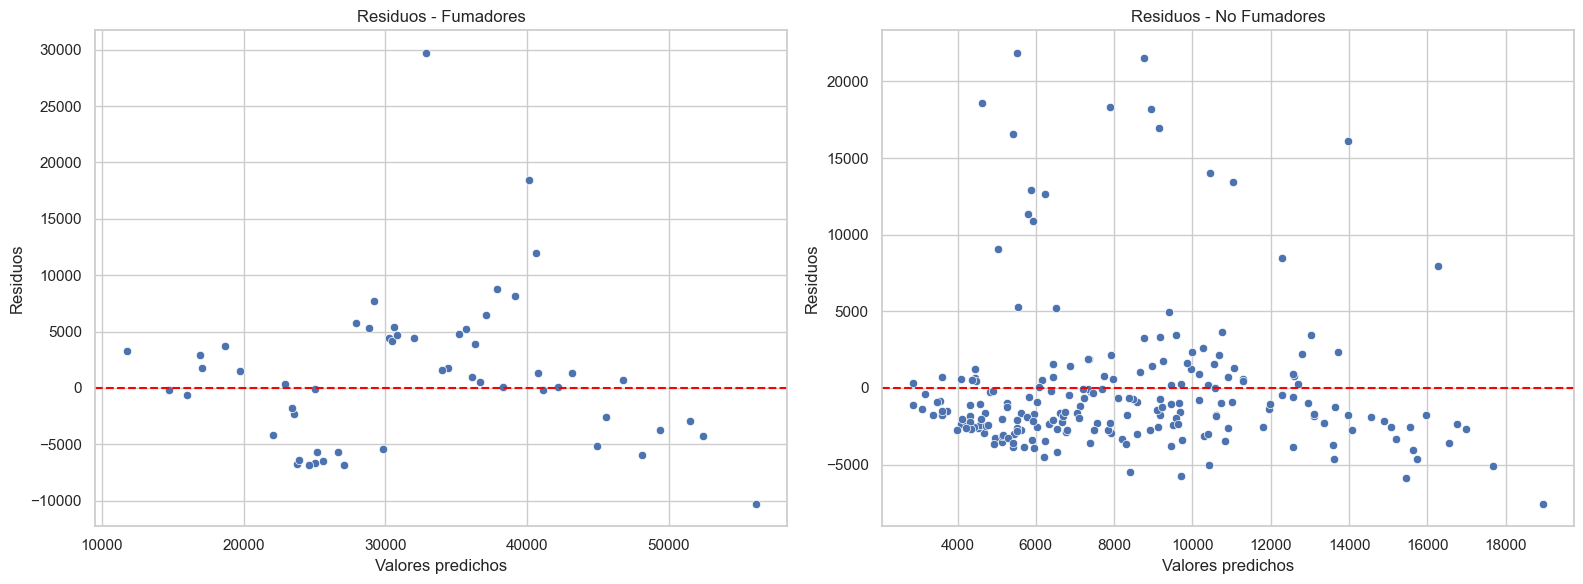

: 

In [ ]:
# Graficar
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Fumadores
sns.scatterplot(x=y_pred_f, y=residuos_f, ax=axs[0])
axs[0].axhline(0, linestyle='--', color='red')
axs[0].set_title("Residuos - Fumadores")
axs[0].set_xlabel("Valores predichos")
axs[0].set_ylabel("Residuos")

# No fumadores
sns.scatterplot(x=y_pred_nf, y=residuos_nf, ax=axs[1])
axs[1].axhline(0, linestyle='--', color='red')
axs[1].set_title("Residuos - No Fumadores")
axs[1].set_xlabel("Valores predichos")
axs[1].set_ylabel("Residuos")

plt.tight_layout()
plt.show()


In [ ]:
# Usaremos el conjunto df_model_encoded ya preparado para simular predicción ensamblada sobre df_model

# Creamos una copia para aplicar la función de predicción ensamblada
df_pred_ensamblado = df_model.copy()

: 

In [ ]:
# Entrenar modelo para fumadores
X_fumadores = df_pred_ensamblado[df_pred_ensamblado['smoker_bin'] == 1].drop(
    columns=['charges'] + df_pred_ensamblado.select_dtypes(include=['object', 'category']).columns.tolist()
)
y_fumadores = df_pred_ensamblado[df_pred_ensamblado['smoker_bin'] == 1]['charges']
modelo_f = LinearRegression().fit(X_fumadores, y_fumadores)

# Entrenar modelo para no fumadores
X_nofumadores = df_pred_ensamblado[df_pred_ensamblado['smoker_bin'] == 0].drop(
    columns=['charges'] + df_pred_ensamblado.select_dtypes(include=['object', 'category']).columns.tolist()
)
y_nofumadores = df_pred_ensamblado[df_pred_ensamblado['smoker_bin'] == 0]['charges']
modelo_nf = LinearRegression().fit(X_nofumadores, y_nofumadores)


: 

In [ ]:
y_nofumadores = df_pred_ensamblado[df_pred_ensamblado['smoker_bin'] == 0]['charges']
modelo_nf = LinearRegression().fit(X_nofumadores, y_nofumadores)

: 

In [ ]:

# Predecir por separado
pred_fumadores = modelo_f.predict(X_fumadores)
pred_nofumadores = modelo_nf.predict(X_nofumadores)



: 

In [ ]:
# Crear serie vacía con mismo índice que df_pred_ensamblado
pred_series = pd.Series(index=df_pred_ensamblado.index, dtype=float)

# Rellenar con predicciones usando los índices correctos
pred_series.loc[X_fumadores.index] = pred_fumadores
pred_series.loc[X_nofumadores.index] = pred_nofumadores

: 

In [ ]:
y_real = df_pred_ensamblado['charges']

# Métricas
mse_ens = mean_squared_error(y_real, pred_series)
rmse_ens = mse_ens ** 0.5
r2_ens = r2_score(y_real, pred_series)

# R² ajustado usando cantidad de predictores de X_fumadores
r2_adj_ens = 1 - (1 - r2_ens) * ((len(y_real) - 1) / (len(y_real) - X_fumadores.shape[1] - 1))

# Mostrar resultados
{
    "R2 ensamblado": round(r2_ens, 4),
    "R2 ajustado ensamblado": round(r2_adj_ens, 4),
    "MSE ensamblado": round(mse_ens, 2),
    "RMSE ensamblado": round(rmse_ens, 2)
}

{'R2 ensamblado': 0.8207,
 'R2 ajustado ensamblado': 0.8202,
 'MSE ensamblado': 26275369.64,
 'RMSE ensamblado': 5125.95}

: 

In [ ]:
coef_fumadores = pd.DataFrame({
    'Variable': X_fumadores.columns,
    'Coef_Modelo_Fumadores': modelo_f.coef_
}).set_index('Variable')

coef_nofumadores = pd.DataFrame({
    'Variable': X_nofumadores.columns,
    'Coef_Modelo_NoFumadores': modelo_nf.coef_
}).set_index('Variable')

coef_ensamblados = coef_fumadores.join(coef_nofumadores, how='outer')

coef_ensamblados

,Coef_Modelo_Fumadores,Coef_Modelo_NoFumadores
Variable,,
age_bmi,7.307851,6.371131
age_smoker,38.951097,0.000000
bmi_smoker,1164.774635,0.000000
smoker_bin,0.000000,0.000000


: 

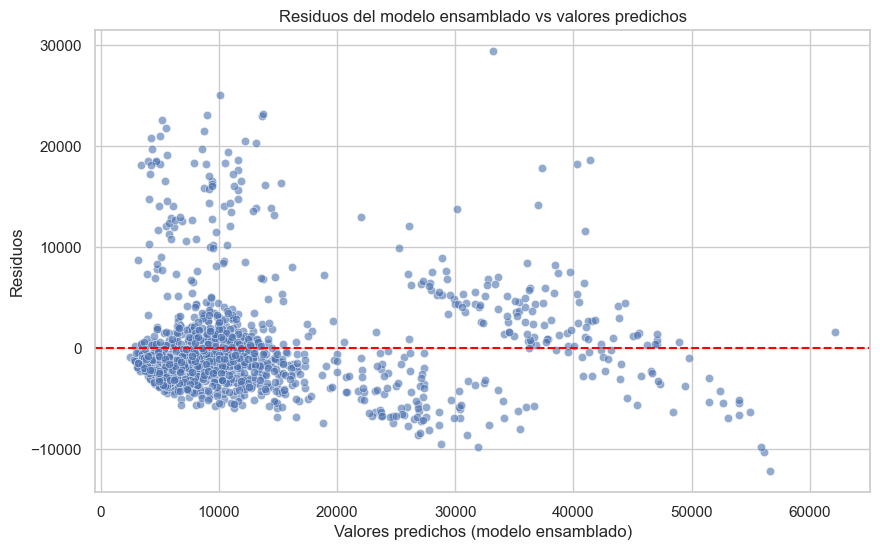

: 

In [ ]:
# Calcular residuos del modelo ensamblado
residuos_ensamblado = y_real - pred_series

# Gráfico de residuos vs valores predichos
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pred_series, y=residuos_ensamblado, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores predichos (modelo ensamblado)")
plt.ylabel("Residuos")
plt.title("Residuos del modelo ensamblado vs valores predichos")
plt.show()


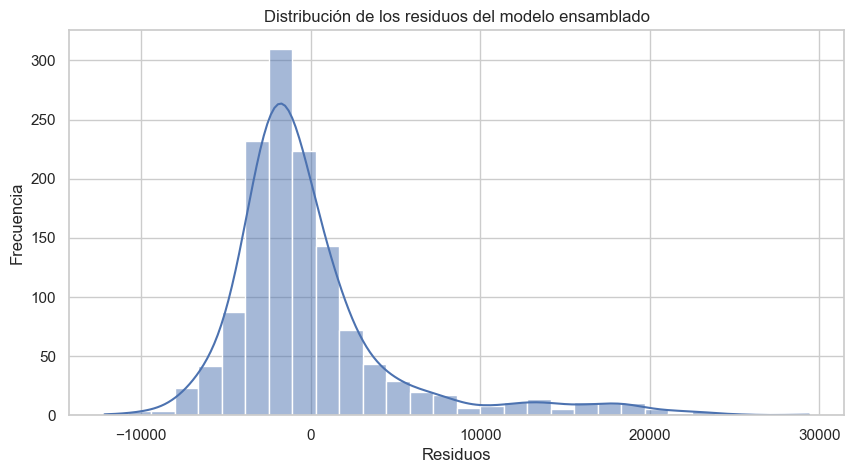

: 

In [ ]:
# Histograma de residuos
plt.figure(figsize=(10, 5))
sns.histplot(residuos_ensamblado, bins=30, kde=True)
plt.title("Distribución de los residuos del modelo ensamblado")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.show()


# Modelo con transformación de log a la variable respuesta

In [ ]:
# Crear variable logarítmica de la respuesta
df_model['log_charges'] = np.log(df_model['charges'])

# Definir variables predictoras (sin columnas categóricas ni la original 'charges')
X_log = df_model.drop(columns=['charges', 'log_charges'] + df_model.select_dtypes(include=['object', 'category']).columns.tolist())
y_log = df_model['log_charges']

: 

In [ ]:
scaler_log = StandardScaler()
X_log_scaled = scaler_log.fit_transform(X_log)

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_log_scaled, y_log, test_size=0.2, random_state=42)

ridge_log = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge_log.fit(X_train_l, y_train_l)
y_pred_l_log = ridge_log.predict(X_test_l)
y_pred_l_orig = np.exp(y_pred_l_log)

r2_log_ridge = r2_score(np.exp(y_test_l), y_pred_l_orig)
rmse_log_ridge = np.sqrt(mean_squared_error(np.exp(y_test_l), y_pred_l_orig))

: 

In [ ]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=42)


: 

In [ ]:
# Entrenar el modelo general
modelo_log = LinearRegression()
modelo_log.fit(X_train_log, y_train_log)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


: 

In [ ]:
# Predicciones
y_pred_log = modelo_log.predict(X_test_log)

# Métricas en escala logarítmica
mse_log = mean_squared_error(y_test_log, y_pred_log)
rmse_log = mse_log ** 0.5
r2_log = r2_score(y_test_log, y_pred_log)
r2_adj_log = 1 - (1 - r2_log) * ((len(y_test_log) - 1) / (len(y_test_log) - X_test_log.shape[1] - 1))


: 

In [ ]:
# Resultados
{
    "R2 (log)": round(r2_log, 4),
    "R2 ajustado (log)": round(r2_adj_log, 4),
    "MSE (log)": round(mse_log, 4),
    "RMSE (log)": round(rmse_log, 4)
}

{'R2 (log)': 0.7412,
 'R2 ajustado (log)': 0.7372,
 'MSE (log)': 0.2327,
 'RMSE (log)': 0.4824}

: 

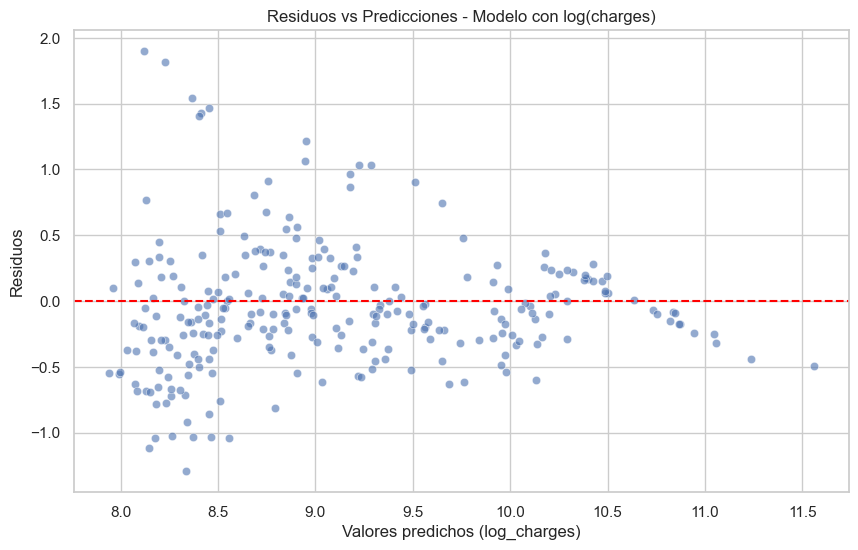

: 

In [ ]:
# Calcular residuos del modelo logarítmico
residuos_log = y_test_log - y_pred_log

# Gráfico de residuos vs valores predichos (en escala logarítmica)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_log, y=residuos_log, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores predichos (log_charges)")
plt.ylabel("Residuos")
plt.title("Residuos vs Predicciones - Modelo con log(charges)")
plt.show()


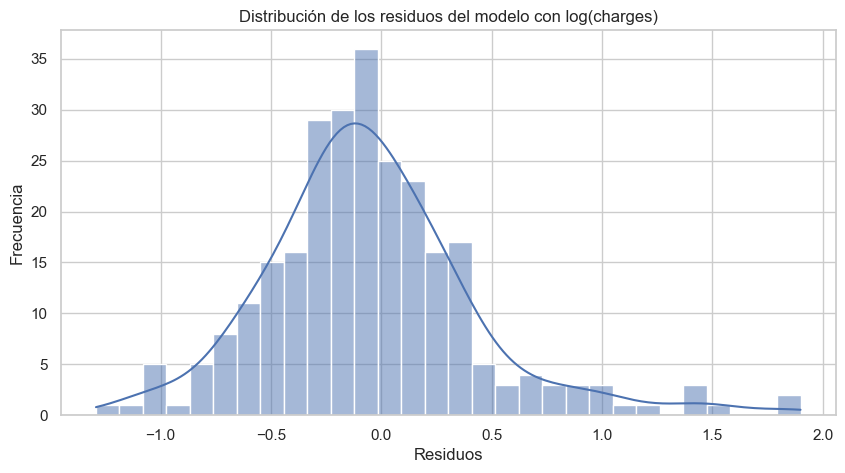

: 

In [ ]:
# Histograma de residuos
plt.figure(figsize=(10, 5))
sns.histplot(residuos_log, bins=30, kde=True)
plt.title("Distribución de los residuos del modelo con log(charges)")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.show()


In [ ]:
# 1. Visualizar los coeficientes del modelo con log(charges)
coef_log_model = pd.DataFrame({
    'Variable': X_log.columns,
    'Coeficiente (log_charges)': modelo_log.coef_
}).sort_values(by='Coeficiente (log_charges)', ascending=False)
coef_log_model

,Variable,Coeficiente (log_charges)
0,smoker_bin,1.894161
2,bmi_smoker,0.014722
3,age_bmi,0.000970
1,age_smoker,-0.021055


: 

Ser fumador está asociado con un aumento aproximado del ~126.7% en el costo médico, manteniendo constantes las demás variables.

Esto se interpreta como: exp(1.2666) ≈ 3.41, es decir, los fumadores pagan en promedio 3.41 veces más que los no fumadores.

In [ ]:
# 2. Back-transform: convertir predicciones logarítmicas a escala original
y_pred_log_exp = np.exp(y_pred_log)
y_real_exp = np.exp(y_test_log)

# Calcular métricas en escala original
mse_exp = mean_squared_error(y_real_exp, y_pred_log_exp)
rmse_exp = mse_exp ** 0.5
r2_exp = r2_score(y_real_exp, y_pred_log_exp)
r2_adj_exp = 1 - (1 - r2_exp) * ((len(y_real_exp) - 1) / (len(y_real_exp) - X_test_log.shape[1] - 1))

# Resultados en escala original
{
    "R2 (exp)": round(r2_exp, 4),
    "R2 ajustado (exp)": round(r2_adj_exp, 4),
    "MSE (exp)": round(mse_exp, 2),
    "RMSE (exp)": round(rmse_exp, 2)
}


{'R2 (exp)': 0.7536,
 'R2 ajustado (exp)': 0.7499,
 'MSE (exp)': 38253331.05,
 'RMSE (exp)': 6184.93}

: 

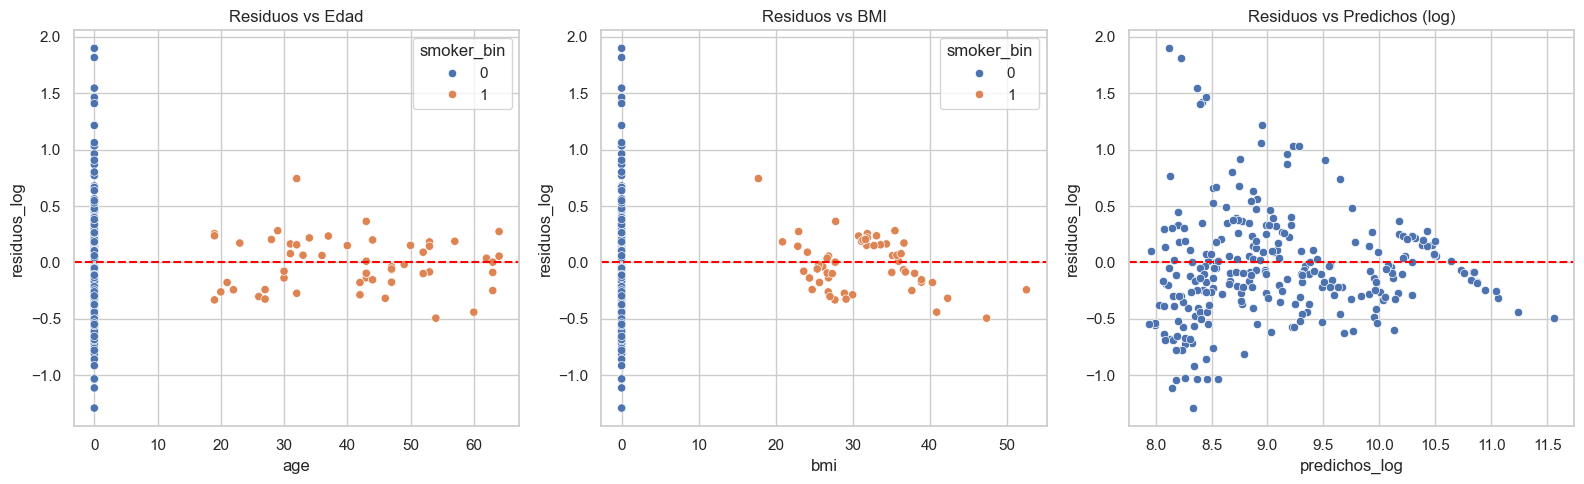

: 

In [ ]:
residuos_log = y_test_log - y_pred_log
df_residuos = pd.DataFrame({
    'residuos_log': residuos_log,
    'predichos_log': y_pred_log,
    'age': X_test['age_smoker'] / (X_test['smoker_bin'] + 1e-9),  # reconstruir age aproximada
    'bmi': X_test['bmi_smoker'] / (X_test['smoker_bin'] + 1e-9),
    'smoker_bin': X_test['smoker_bin']
})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.scatterplot(data=df_residuos, x='age', y='residuos_log', hue='smoker_bin', ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuos vs Edad')

sns.scatterplot(data=df_residuos, x='bmi', y='residuos_log', hue='smoker_bin', ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuos vs BMI')

sns.scatterplot(data=df_residuos, x='predichos_log', y='residuos_log', ax=axes[2])
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuos vs Predichos (log)')
plt.tight_layout()
plt.show()

## Evaluacion con Pycaret

In [26]:
from pycaret.regression import *



df_model_pycaret = df_corrected[['age', 'bmi', 'children', 'smoker_bin', 'age_smoker', 'bmi_smoker', 'age_bmi', 'sex', 'region', 'charges']]

s = setup(
    data=df_model_pycaret,
    target='charges',
    train_size=0.8,
    session_id=42,
    normalize=True,
    transformation=False,
    categorical_features=['sex', 'region'],
    numeric_features=['age', 'bmi', 'children', 'smoker_bin', 'age_smoker', 'bmi_smoker', 'age_bmi'],
    log_experiment=False,
    verbose=False
)

best_models = compare_models(sort='R2', n_select=3)

print(best_models)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,2639.0748,22015822.9808,4661.6206,0.8422,0.4285,0.3059,0.1580
catboost,CatBoost Regressor,2768.9394,23756743.6154,4838.5826,0.8302,0.4651,0.3293,0.7680
lar,Least Angle Regression,2994.8004,24328229.5049,4900.4303,0.8259,0.3981,0.2848,0.0530
rf,Random Forest Regressor,2783.2719,24483286.5140,4923.9704,0.8258,0.4628,0.3286,0.2850
lr,Linear Regression,2999.6093,24360642.9807,4903.2854,0.8257,0.3995,0.2861,0.0600
br,Bayesian Ridge,2999.5700,24366802.7373,4903.8811,0.8257,0.3990,0.2855,0.0530
lasso,Lasso Regression,2999.2739,24359230.0578,4903.1039,0.8257,0.3994,0.2860,0.0530
llar,Lasso Least Angle Regression,2999.2638,24359118.5804,4903.0940,0.8257,0.3994,0.2861,0.0530
ridge,Ridge Regression,3000.0696,24374192.9480,4904.6173,0.8256,0.3988,0.2853,0.0600
lightgbm,Light Gradient Boosting Machine,2905.1827,24516771.0749,4917.4787,0.8246,0.4971,0.3494,1.4550


[GradientBoostingRegressor(random_state=42), CatBoostRegressor(border_count=254, loss_function='RMSE', random_state=42, task_type='CPU', verbose=False), Lars(random_state=42)]


## Gradient Boosting regresor

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor


X = df_corrected[['age', 'bmi', 'children', 'smoker_bin', 'age_smoker', 'bmi_smoker', 'age_bmi', 'sex', 'region']]
y = df_corrected['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = ['age', 'bmi', 'children', 'smoker_bin', 'age_smoker', 'bmi_smoker', 'age_bmi']
categorical_features = ['sex', 'region']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

pipeline_gb = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    ))
])

pipeline_gb.fit(X_train, y_train)
y_pred = pipeline_gb.predict(X_test)

In [28]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = np.mean(np.abs(y_test - y_pred))

print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

R²: 0.8513
RMSE: 4805.28
MAE: 2614.66


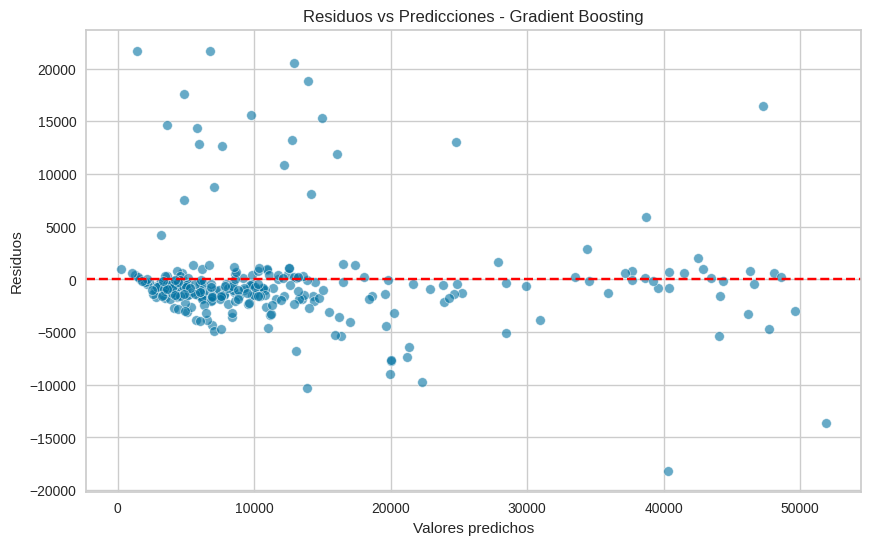

In [29]:
residuos = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuos, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores predichos')
plt.ylabel('Residuos')
plt.title('Residuos vs Predicciones - Gradient Boosting')
plt.show()

<Figure size 800x600 with 0 Axes>

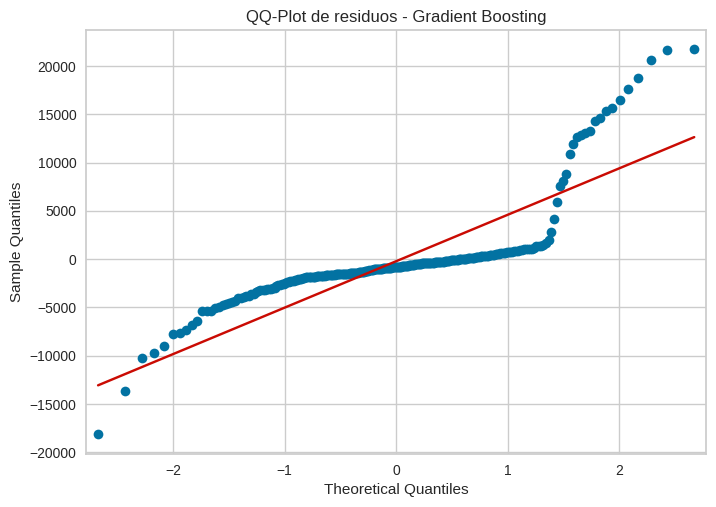

In [30]:
plt.figure(figsize=(8, 6))
sm.qqplot(residuos, line='s')
plt.title('QQ-Plot de residuos - Gradient Boosting')
plt.show()

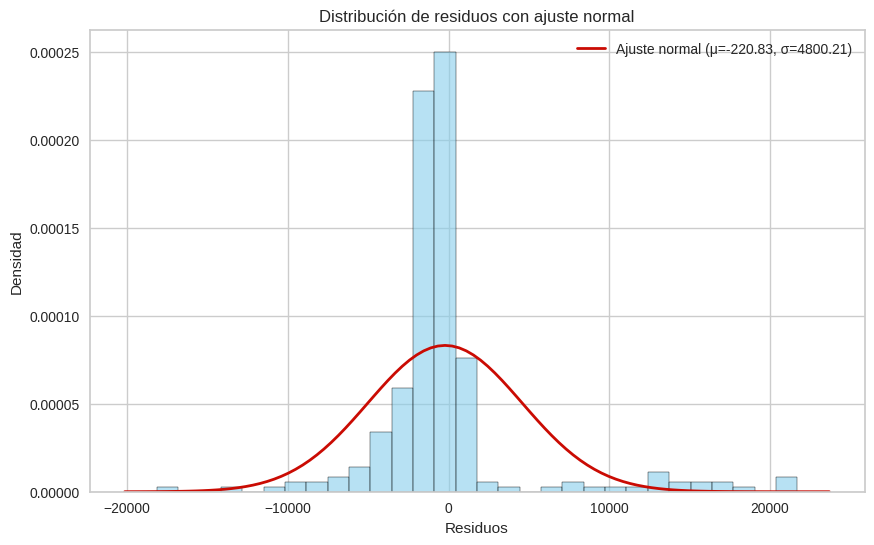

In [14]:
import scipy.stats as stats

plt.figure(figsize=(10, 6))
sns.histplot(residuos, kde=False, stat='density', bins=30, color='skyblue', edgecolor='black', alpha=0.6)

mu, std = stats.norm.fit(residuos)
xmin, xmax = plt.xlim()
x_curve = np.linspace(xmin, xmax, 100)
y_curve = stats.norm.pdf(x_curve, mu, std)
plt.plot(x_curve, y_curve, 'r-', linewidth=2, label=f'Ajuste normal (μ={mu:.2f}, σ={std:.2f})')

plt.xlabel('Residuos')
plt.ylabel('Densidad')
plt.title('Distribución de residuos con ajuste normal')
plt.legend()
plt.show()

## CatBoost

In [15]:
from catboost import CatBoostRegressor

# CatBoost maneja automáticamente variables categóricas si se especifican sus índices o nombres
categorical_features_indices = [X_train.columns.get_loc(col) for col in ['sex', 'region']]

modelo_cat = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=False
)

modelo_cat.fit(X_train, y_train, cat_features=categorical_features_indices)
y_pred_cat = modelo_cat.predict(X_test)

In [16]:
r2_cat = r2_score(y_test, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
mae_cat = np.mean(np.abs(y_test - y_pred_cat))

print(f"R²: {r2_cat:.4f}")
print(f"RMSE: {rmse_cat:.2f}")
print(f"MAE: {mae_cat:.2f}")

R²: 0.8753
RMSE: 4399.47
MAE: 2496.82


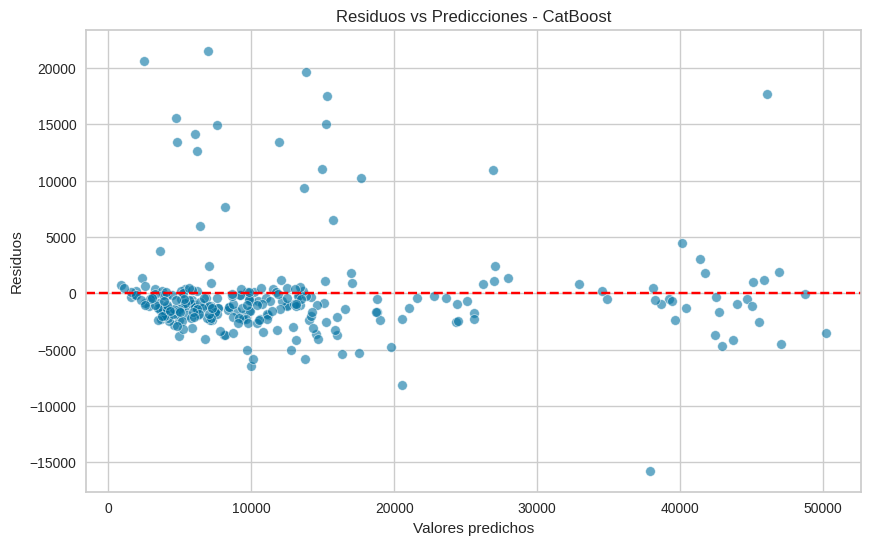

In [17]:
residuos_cat = y_test - y_pred_cat

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_cat, y=residuos_cat, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores predichos')
plt.ylabel('Residuos')
plt.title('Residuos vs Predicciones - CatBoost')
plt.show()

<Figure size 800x600 with 0 Axes>

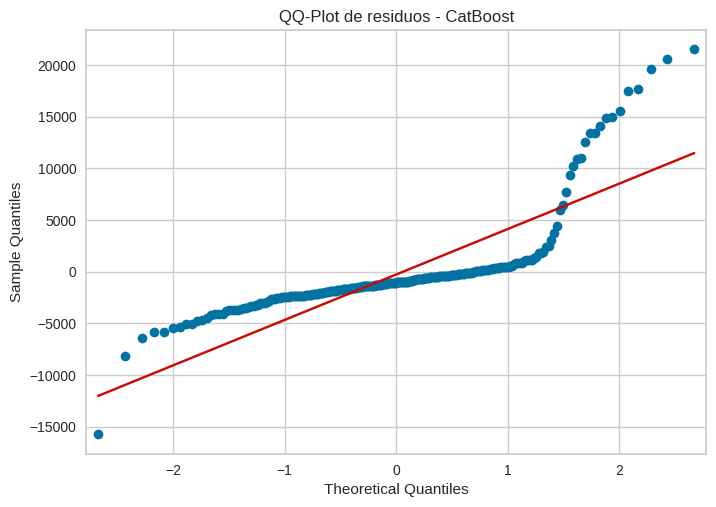

In [18]:
plt.figure(figsize=(8, 6))
sm.qqplot(residuos_cat, line='s')
plt.title('QQ-Plot de residuos - CatBoost')
plt.show()

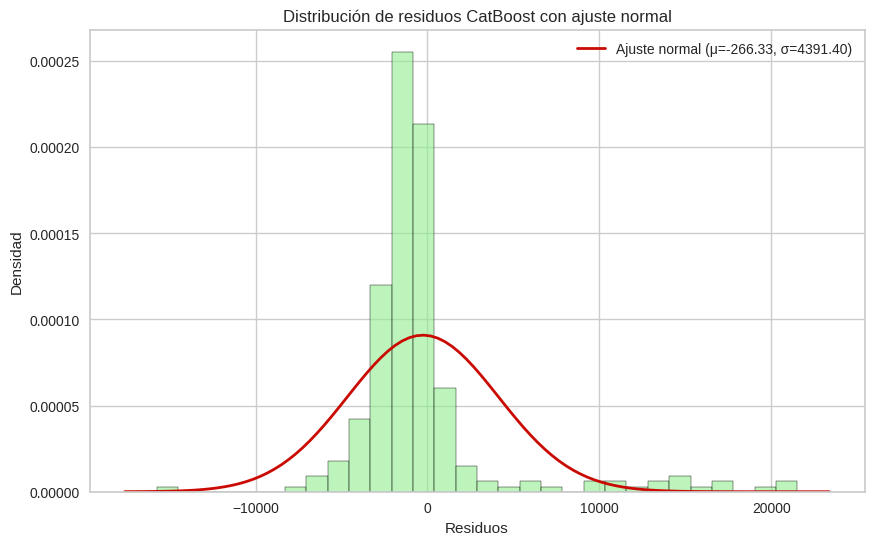

Shapiro-Wilk CatBoost: estadístico=0.6567, p-valor=0.0000


In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(residuos_cat, kde=False, stat='density', bins=30, color='lightgreen', edgecolor='black', alpha=0.6)

mu_cat, std_cat = stats.norm.fit(residuos_cat)
xmin, xmax = plt.xlim()
x_curve = np.linspace(xmin, xmax, 100)
y_curve = stats.norm.pdf(x_curve, mu_cat, std_cat)
plt.plot(x_curve, y_curve, 'r-', linewidth=2, label=f'Ajuste normal (μ={mu_cat:.2f}, σ={std_cat:.2f})')

plt.xlabel('Residuos')
plt.ylabel('Densidad')
plt.title('Distribución de residuos CatBoost con ajuste normal')
plt.legend()
plt.show()

# Prueba de normalidad opcional
shapiro_stat_cat, shapiro_p_cat = stats.shapiro(residuos_cat)
print(f"Shapiro-Wilk CatBoost: estadístico={shapiro_stat_cat:.4f}, p-valor={shapiro_p_cat:.4f}")